# FraudShield -- CNN Image Classification (SageMaker Studio)

This notebook runs the CNN image classification workflow interactively inside SageMaker Studio, using the **built-in Image Classification algorithm** with transfer learning (MobileNet V2).

It mirrors Steps 5, 6, 10, 11, and 11b of the lecture notebook, but broken into cells you can step through and inspect.

**Prerequisites:**
- SageMaker Studio Domain is **InService** (Step 2)
- This notebook is uploaded to SageMaker Studio
- Select the **Python 3 (Data Science 3.0)** kernel when prompted

In [26]:
%pip install -q numpy matplotlib pandas boto3 sagemaker Pillow sagemaker-core

Note: you may need to restart the kernel to use updated packages.


## 1. Environment Setup

Inside SageMaker Studio, the execution role is auto-detected.

In [3]:
import os
import boto3
from sagemaker_core.helper.session_helper import Session, get_execution_role

session = Session()
role = get_execution_role()
bucket = session.default_bucket()
region = session.boto_region_name

print(f"Role:    {role}")
print(f"Bucket:  {bucket}")
print(f"Region:  {region}")

Role:    arn:aws:iam::407975137156:role/service-role/AmazonSageMaker-ExecutionRole-20260327T083133
Bucket:  sagemaker-us-west-2-407975137156
Region:  us-west-2


## 2. Download and Prepare CIFAR-10 Data

The built-in Image Classification algorithm expects images organized into class-specific subdirectories:

```
cifar10_images/training/
  airplane/
    00000.png
    00001.png
  automobile/
    00000.png
    ...
```

We download raw CIFAR-10 data and convert it into `.png` files.

/tmp/ipykernel_243/3141227440.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Prepared 50000 images across 10 classes
Output directory: cifar10_images/training/


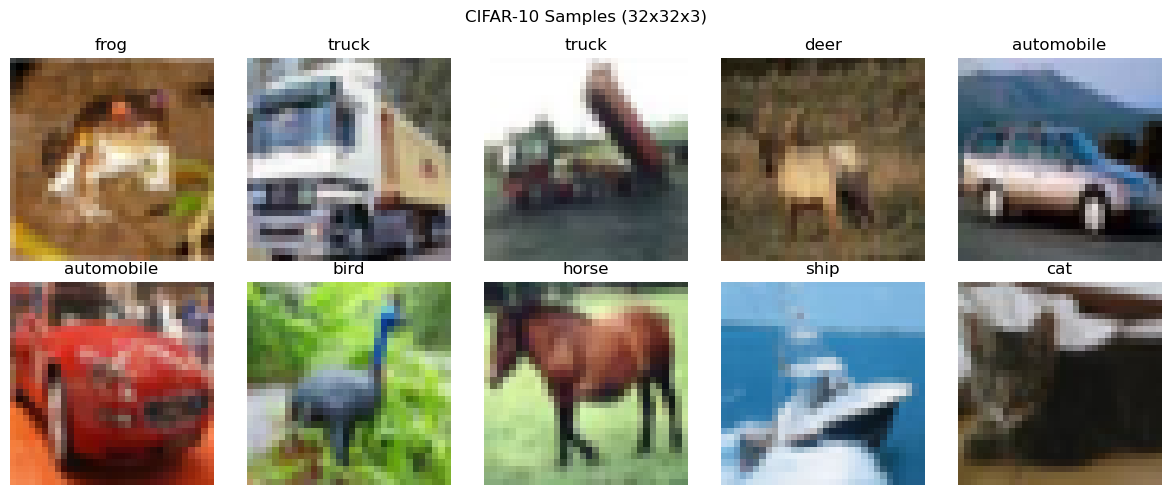

In [43]:
import pickle
import tarfile
import urllib.request
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

CIFAR_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
CIFAR_TAR = "cifar-10-python.tar.gz"
CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

if not os.path.exists(CIFAR_TAR):
    print("Downloading CIFAR-10...")
    urllib.request.urlretrieve(CIFAR_URL, CIFAR_TAR)

with tarfile.open(CIFAR_TAR) as tar:
    tar.extractall()

def load_batch(path):
    with open(path, "rb") as f:
        d = pickle.load(f, encoding="bytes")
    return d[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1), d[b"labels"]

all_imgs, all_labels = [], []
for i in range(1, 6):
    imgs, lbls = load_batch(f"cifar-10-batches-py/data_batch_{i}")
    all_imgs.append(imgs)
    all_labels.extend(lbls)
all_imgs = np.concatenate(all_imgs)

split = "training"
for cls in CLASSES:
    os.makedirs(f"cifar10_images/{split}/{cls}", exist_ok=True)

for idx, (img, lbl) in enumerate(zip(all_imgs, all_labels)):
    cls_name = CLASSES[lbl]
    Image.fromarray(img).save(f"cifar10_images/{split}/{cls_name}/{idx:05d}.jpg", quality=95)


print(f"Prepared {len(all_imgs)} images across {len(CLASSES)} classes")
print(f"Output directory: cifar10_images/training/")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(all_imgs[i])
    ax.set_title(CLASSES[all_labels[i]])
    ax.axis("off")
plt.suptitle("CIFAR-10 Samples (32x32x3)")
plt.tight_layout()
plt.show()

## 3. Upload Training Data to S3

The built-in algorithm reads images directly from S3.

In [45]:
training_s3_uri = session.upload_data(
    path="cifar10_images/training",
    bucket=bucket,
    key_prefix="fraudshield/cifar10/training",
)

print(f"Training data uploaded to: {training_s3_uri}")
print(f"  (50,000 images across 10 class directories)")

Training data uploaded to: s3://sagemaker-us-west-2-407975137156/fraudshield/cifar10/training
  (50,000 images across 10 class directories)


## 4. Explore the Built-in Algorithm and Default Hyperparameters

SageMaker provides the model, the training script, and the container. We just configure hyperparameters.

**Transfer learning with MobileNet V2:**

| Block | What It Does |
|-------|-------------|
| Input | 224x224x3 image (resized from 32x32 automatically) |
| Depthwise separable convolutions | Lightweight conv blocks |
| Inverted residuals | Expand, depthwise conv, project back with skip connections |
| Global average pooling | Reduces spatial dims to a single vector per channel |
| **Top layer (retrained)** | Dense layer mapping to our 10 classes |

In [46]:
from sagemaker import hyperparameters

MODEL_ID = "tensorflow-ic-imagenet-mobilenet-v2-100-224-classification-4"
MODEL_VERSION = "4.0.25"

default_hp = hyperparameters.retrieve_default(model_id=MODEL_ID, model_version=MODEL_VERSION)

print(f"JumpStart Model: {MODEL_ID}")
print(f"Version:         {MODEL_VERSION}")
print(f"\nDefault hyperparameters:")
for k, v in sorted(default_hp.items()):
    print(f"  {k}: {v}")

JumpStart Model: tensorflow-ic-imagenet-mobilenet-v2-100-224-classification-4
Version:         4.0.25

Default hyperparameters:
  augmentation: False
  augmentation_random_flip: horizontal_and_vertical
  augmentation_random_rotation: 0.2
  augmentation_random_zoom: 0.1
  batch_size: 32
  beta_1: 0.9
  beta_2: 0.999
  binary_mode: False
  dropout_rate: 0.2
  early_stopping: False
  early_stopping_min_delta: 0.0
  early_stopping_patience: 5
  epochs: 5
  epsilon: 1e-07
  eval_metric: accuracy
  image_resize_interpolation: bilinear
  initial_accumulator_value: 0.1
  label_smoothing: 0.1
  learning_rate: 0.001
  momentum: 0.9
  optimizer: adam
  random_seed: 123
  regularizers_l2: 0.0001
  reinitialize_top_layer: Auto
  rho: 0.95
  train_only_top_layer: True
  validation_split_ratio: 0.2


## 5. Configure Custom Hyperparameters

Override the defaults for our CIFAR-10 fine-tuning task.

| Hyperparameter | Default | Our Value | Why |
|---------------|---------|-----------|-----|
| `epochs` | 5 | 5 | Enough for transfer learning convergence |
| `batch_size` | 32 | 32 | Reasonable for the image size |
| `learning_rate` | auto | 0.001 | Conservative for fine-tuning |
| `augmentation` | False | True | Increases effective dataset size |
| `augmentation_random_flip` | horizontal_and_vertical | horizontal | Vertical flip doesn't make sense for most objects |
| `train_only_top_layer` | False | True | Freeze pretrained features, retrain classification head only |

In [47]:
custom_hp = dict(default_hp)
custom_hp["epochs"] = "5"
custom_hp["batch_size"] = "32"
custom_hp["learning_rate"] = "0.001"
custom_hp["augmentation"] = "True"
custom_hp["augmentation_random_flip"] = "horizontal"
custom_hp["augmentation_random_rotation"] = "0.2"
custom_hp["train_only_top_layer"] = "True"

print("Custom hyperparameters for CIFAR-10 fine-tuning:")
for k, v in sorted(custom_hp.items()):
    print(f"  {k}: {v}")

Custom hyperparameters for CIFAR-10 fine-tuning:
  augmentation: True
  augmentation_random_flip: horizontal
  augmentation_random_rotation: 0.2
  augmentation_random_zoom: 0.1
  batch_size: 32
  beta_1: 0.9
  beta_2: 0.999
  binary_mode: False
  dropout_rate: 0.2
  early_stopping: False
  early_stopping_min_delta: 0.0
  early_stopping_patience: 5
  epochs: 5
  epsilon: 1e-07
  eval_metric: accuracy
  image_resize_interpolation: bilinear
  initial_accumulator_value: 0.1
  label_smoothing: 0.1
  learning_rate: 0.001
  momentum: 0.9
  optimizer: adam
  random_seed: 123
  regularizers_l2: 0.0001
  reinitialize_top_layer: Auto
  rho: 0.95
  train_only_top_layer: True
  validation_split_ratio: 0.2


## 6. Launch the Built-in Image Classification Training Job

This submits a managed training job using `ModelTrainer.from_jumpstart_config()`. SageMaker handles:
- Pulling the TensorFlow container with the pretrained MobileNet V2 weights
- Downloading CIFAR-10 images from S3
- Fine-tuning the top classification layer
- Uploading the trained model artifact to S3
- Tearing down the training instance

Estimated runtime: 5-15 minutes depending on instance availability.

In [ ]:
from sagemaker.jumpstart.estimator import JumpStartEstimator

ic_trainer = JumpStartEstimator(
    model_id=MODEL_ID,
    model_version=MODEL_VERSION,
    hyperparameters=custom_hp,
    role=role,
    instance_type="ml.m4.xlarge",
    output_path=f"s3://{bucket}/fraudshield/cnn-output/",
)

print(f"Model:          {MODEL_ID}")
print(f"Instance type:  {ic_trainer.instance_type}")
print(f"Output path:    s3://{bucket}/fraudshield/cnn-output/")
print("Launching built-in Image Classification training...")

ic_trainer.fit({"training": training_s3_uri})

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: mobilenet-v2-100-224-classification-4-2026-03-28-08-03-25-352


Model:          tensorflow-ic-imagenet-mobilenet-v2-100-224-classification-4
Instance type:  ml.m5.xlarge
Output path:    s3://sagemaker-us-west-2-407975137156/fraudshield/cnn-output/
Launching built-in Image Classification training...
2026-03-28 08:03:27 Starting - Starting the training job...
2026-03-28 08:03:44 Starting - Preparing the instances for training...
2026-03-28 08:04:07 Downloading - Downloading input data...............
2026-03-28 08:06:32 Downloading - Downloading the training image...
2026-03-28 08:07:13 Training - Training image download completed. Training in progress.2026-03-28 08:07:16.012298: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:460] Initializing the SageMaker Profiler.
2026-03-28 08:07:16.013196: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:105] SageMaker Profiler is not enabled. The timeline writer thread will not be started, future recorded events will be dropped.
2026-03-28 08:07:16.040471: W tensorflow/core/profiler/interna

## 7. Inspect the Model Artifact

After training completes, the model artifact is a `model.tar.gz` containing a TensorFlow SavedModel.

In [49]:
print(f"Model artifact location: {ic_trainer.model_data}")
print(f"Training job name:       {ic_trainer._latest_training_job.name}")

sm_client = boto3.client("sagemaker")
job_info = sm_client.describe_training_job(
    TrainingJobName=ic_trainer._latest_training_job.name
)

print(f"\nTraining job status:     {job_info['TrainingJobStatus']}")
print(f"Instance type:           {job_info['ResourceConfig']['InstanceType']}")
print(f"Training duration (sec): {job_info.get('TrainingTimeInSeconds', 'N/A')}")
print(f"Billable duration (sec): {job_info.get('BillableTimeInSeconds', 'N/A')}")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱  1 print(f"Model artifact location: {ic_trainer.model_data}")                                  │
│    2 print(f"Training job name:       {ic_trainer._latest_training_job.name}")                   │
│    3                                                                                             │
│    4 sm_client = boto3.client("sagemaker")                                                       │
│                                                                                                  │
│ /opt/conda/lib/python3.12/site-packages/sagemaker/estimator.py:1889 in model_data                │
│                                                                                                  │
│   1886 │   │   │   job_details = self.sagemaker_session.sagemaker_client.describe_training_job(  │
│   1887 │   │   │   │   TrainingJobName=self.latest_training_job.name                             │
│   1888 │   │   │   )                                                                             │
│ ❱ 1889 │   │   │   model_uri = job_details["ModelArtifacts"]["S3ModelArtifacts"]                 │
│   1890 │   │   │   compression_type = job_details.get("OutputDataConfig", {}).get(               │
│   1891 │   │   │   │   "CompressionType", "GZIP"                                                 │
│   1892 │   │   │   )                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
KeyError: 'ModelArtifacts'

## Comparison: sklearn Script Mode vs. Built-in Image Classification

| Aspect | sklearn (Script Mode) | Image Classification (Built-in) |
|--------|----------------------|-------------------------------|
| Training script | You write `train.py` | SageMaker provides `transfer_learning.py` |
| Model architecture | You define it | Pretrained MobileNet V2 (or ResNet, etc.) |
| Data format | CSV files | PNG images in class directories |
| Hyperparameters | Via `argparse` in your script | Via JumpStart config dict |
| Augmentation | Manual transforms in code | Hyperparameter toggles |
| Instance type | CPU (`ml.m5.xlarge`) | GPU (`ml.p3.2xlarge`) recommended |
| Model artifact | `model.pkl` (joblib) | TensorFlow SavedModel |

**Takeaway:** Built-in algorithms trade flexibility for speed. When a pretrained model covers your use case, they eliminate boilerplate and reduce training time through transfer learning.

## Cleanup Reminder

When you are done:

1. **Shut down this kernel** -- File > Shut Down to stop billing on the Studio instance.
2. Training jobs are already torn down automatically after completion.
3. S3 data and model artifacts persist until you delete them (covered in Step 19 of the lecture notebook).